In [40]:
import os
import re
from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

sns.set_style("whitegrid")

# Create output folders
os.makedirs("../reports/figures", exist_ok=True)

In [41]:
df = pd.read_csv("../data/processed/task2_output.csv")

# Standardize column naming conventions safely
df.columns = df.columns.str.lower()
column_mapping = {'bank': 'bank_name', 'review': 'review_text', 'date': 'review_date'}
df.rename(columns={k: v for k, v in column_mapping.items() if k in df.columns}, inplace=True)

# 2. Complete Finalized Stopword Definitions
stopwords = set([
    # Standard English Grammar
    "the", "and", "for", "that", "this", "with", "have", "from", "your",
    "they", "their", "there", "about", "would", "could", "should", "very", 
    "just", "been", "you", "are", "was", "were", "but", "not", "can", "when", 
    "what", "why", "how", "all", "any", "our", "out", "get", "got", "had", 
    "has", "did", "does", "doing",
    
    # Textual / Speech Fillers & Token Leaks
    "after", "doesn", "even", "more", "time", "other", "ever", "need", "really",
    "some", "only", "make", "most", "much", "open", "apps", "better", "well", 
    "always", "keep", "will", "than", "using", "used", "previous", "ahead", 
    "step", "sometimes", "because", "option", "needs", "services", "keeps", 
    "many", "show", "before", "makes", "properly", "choice",
    
    # Non-Descriptive Praise & Platform Context Fillers
    "thanks", "thank", "good", "best", "great", "nice", "awesome", "excellent",
    "service", "like", "please", "user", "features", "friendly", "experience", "poor",
    "app", "bank", "dashen", "cbe", "abyssinia", "banking", "mobile", 
    "application", "work", "working", "update", "problem", "worst", "super"
])

def clean_tokens(text):
    """Tokenizes alphanumeric text preserving words >= 4 letters without stopwords."""
    tokens = re.findall(r'\b[a-zA-Z]{4,}\b', str(text).lower())
    return [word for word in tokens if word not in stopwords]

# 3. Execution Point: Print Descriptive Diagnostics
print("DataFrame Preview Head:\n", df.head())
print("\nDataset Technical Details:\n")
df.info()


DataFrame Preview Head:
   review_id         review_text bank_name  rating review_date sentiment_label  \
0     rev_0                Good  CBE Bank       5  2026-05-16        Positive   
1     rev_1                🤙🏼🤙🏼  CBE Bank       5  2026-05-16        Negative   
2     rev_2               worst  CBE Bank       1  2026-05-16        Negative   
3     rev_3  this app very full  CBE Bank       5  2026-05-16        Positive   
4     rev_4           good apps  CBE Bank       4  2026-05-16        Positive   

   sentiment_score  identified_theme  
0           0.9998  General Feedback  
1           0.6971  General Feedback  
2           0.9998  General Feedback  
3           0.9974  General Feedback  
4           0.9999  General Feedback  

Dataset Technical Details:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   review_id         88

In [42]:
avg_rating = df.groupby("bank_name")["rating"].mean().sort_values(ascending=False)
print("\nAverage Star Rating Per Bank Profile:\n", avg_rating)

sentiment_dist = df.groupby(["bank_name", "sentiment_label"]).size().unstack(fill_value=0)
print("\nRaw Polarity Distribution Profiles:\n", sentiment_dist)



Average Star Rating Per Bank Profile:
 bank_name
Dashen Bank          4.036866
CBE Bank             3.823214
Bank of Abyssinia    2.964725
Name: rating, dtype: float64

Raw Polarity Distribution Profiles:
 sentiment_label    Negative  Neutral  Positive
bank_name                                     
Bank of Abyssinia       752        6       461
CBE Bank               2921       84      3715
Dashen Bank             303        2       563


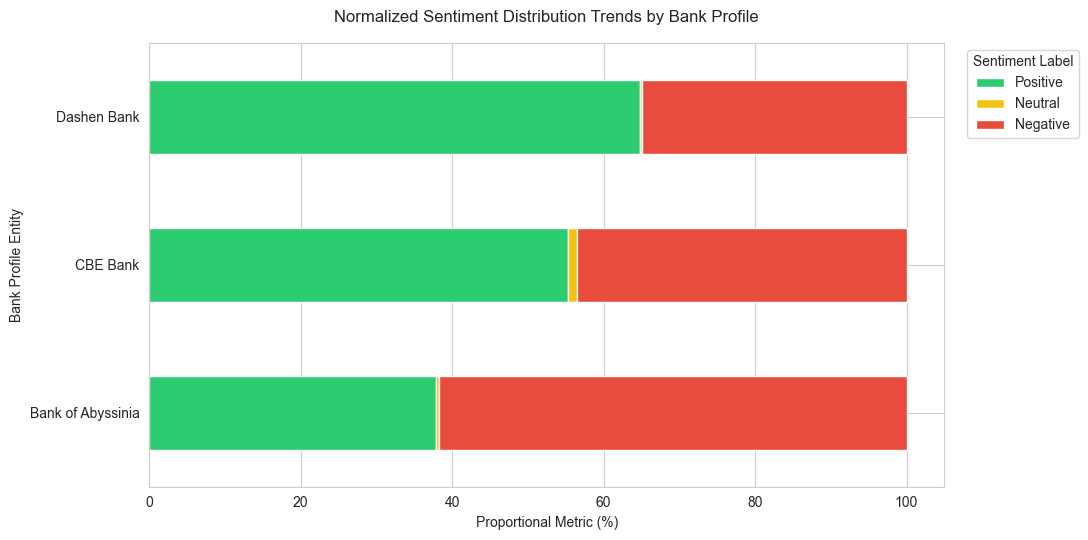

In [43]:
cols_order = [c for c in ['Positive', 'Neutral', 'Negative'] if c in sentiment_dist.columns]
sentiment_pct = (sentiment_dist[cols_order].div(sentiment_dist.sum(axis=1), axis=0) * 100)

ax = sentiment_pct.plot(kind="barh", stacked=True, figsize=(11, 5.5), color=['#2ecc71', '#f1c40f', '#e74c3c'])
plt.title("Normalized Sentiment Distribution Trends by Bank Profile", pad=15)
plt.xlabel("Proportional Metric (%)")
plt.ylabel("Bank Profile Entity")
plt.legend(title="Sentiment Label", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../reports/figures/sentiment_distribution.png", dpi=300)
plt.show()


/tmp/ipykernel_12600/1130978901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="bank_name", y="rating", palette="Set2", width=0.45)


<function matplotlib.pyplot.show(close=None, block=None)>

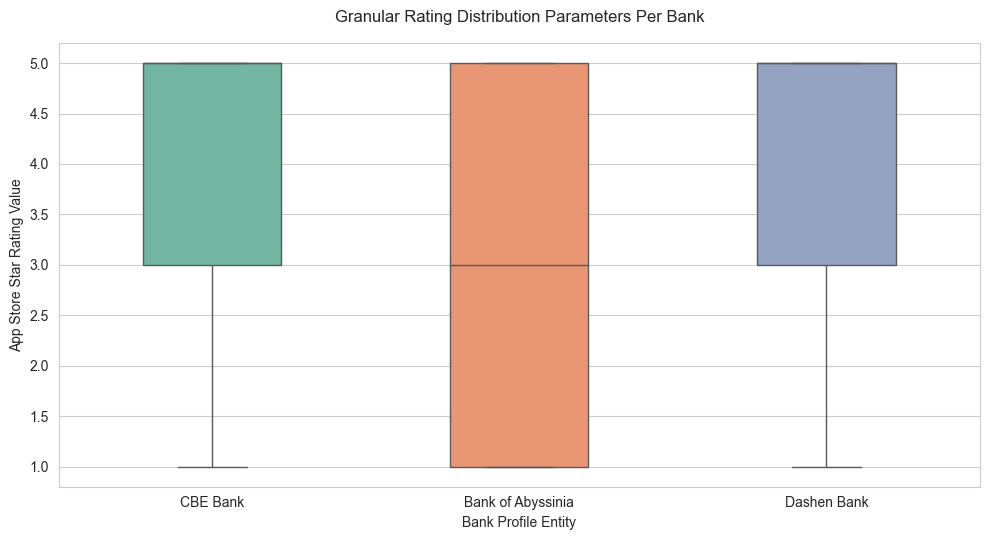

In [44]:
plt.figure(figsize=(10, 5.5))
sns.boxplot(data=df, x="bank_name", y="rating", palette="Set2", width=0.45)
plt.title("Granular Rating Distribution Parameters Per Bank", pad=15)
plt.xlabel("Bank Profile Entity")
plt.ylabel("App Store Star Rating Value")
plt.tight_layout()
plt.savefig("../reports/figures/rating_distribution.png", dpi=300)
plt.show

/tmp/ipykernel_12600/1583310168.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=keywords_df, x="count", y="keyword", palette=palette_theme)


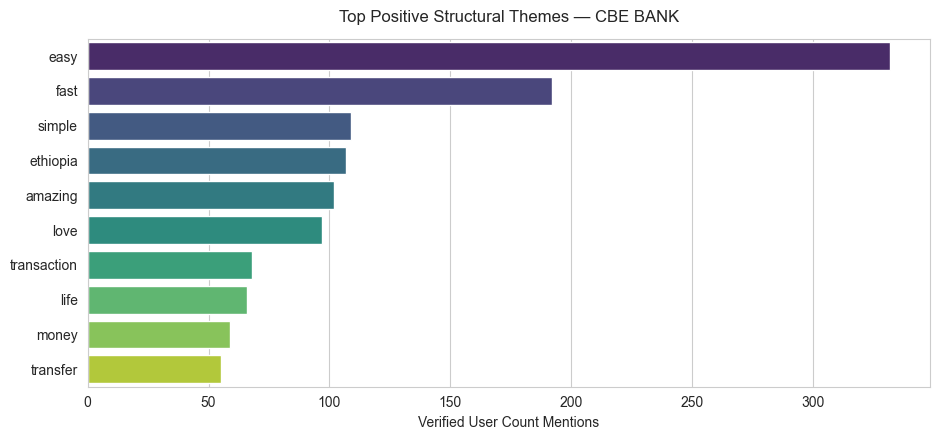

/tmp/ipykernel_12600/1583310168.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=keywords_df, x="count", y="keyword", palette=palette_theme)


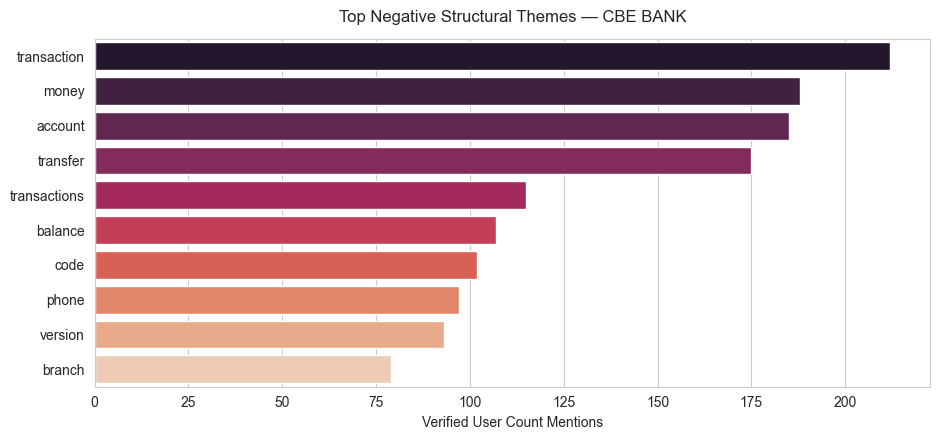

/tmp/ipykernel_12600/1583310168.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=keywords_df, x="count", y="keyword", palette=palette_theme)


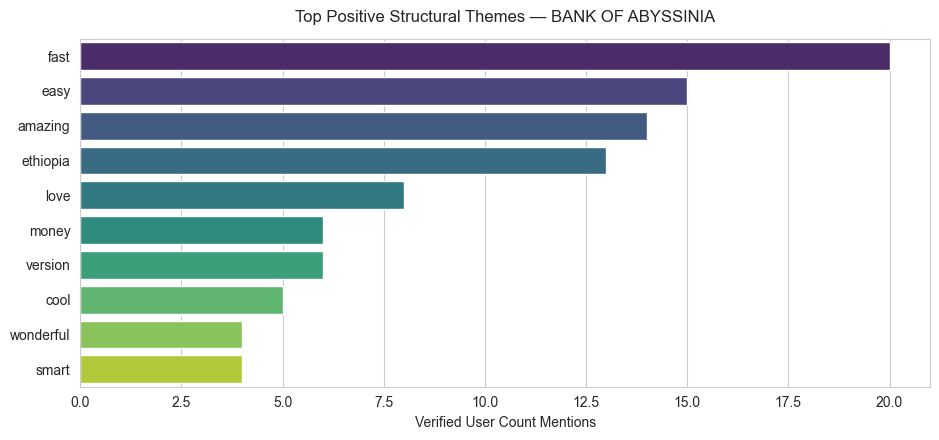

/tmp/ipykernel_12600/1583310168.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=keywords_df, x="count", y="keyword", palette=palette_theme)


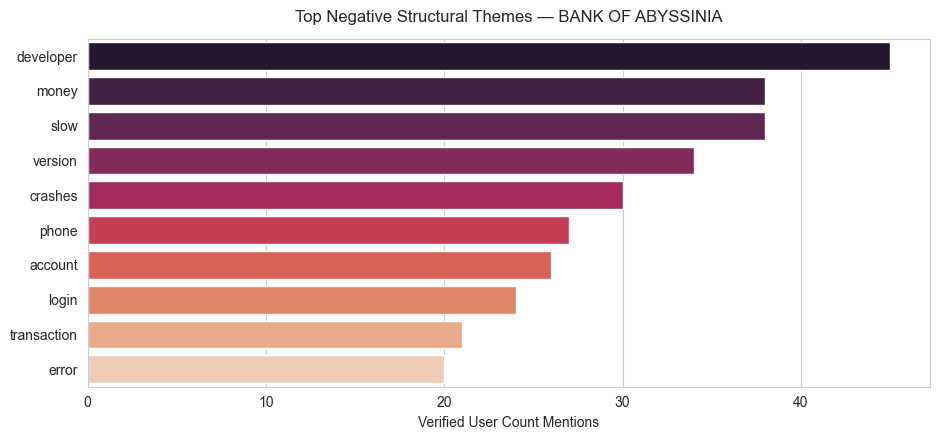

/tmp/ipykernel_12600/1583310168.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=keywords_df, x="count", y="keyword", palette=palette_theme)


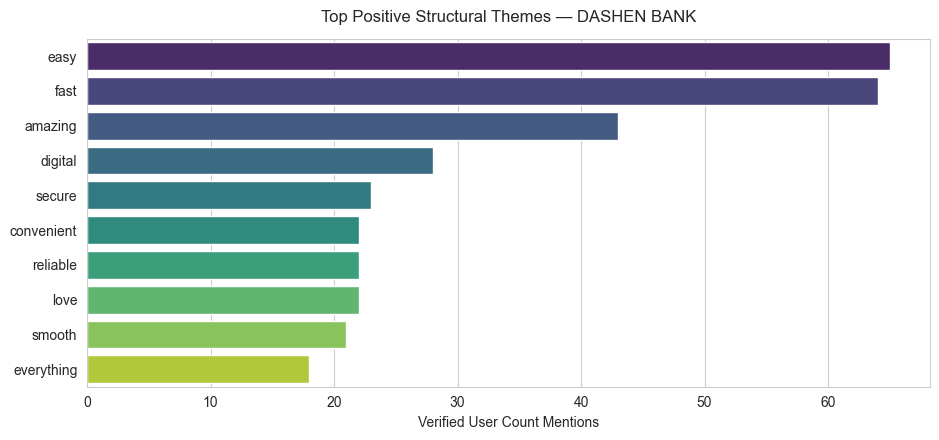

/tmp/ipykernel_12600/1583310168.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=keywords_df, x="count", y="keyword", palette=palette_theme)


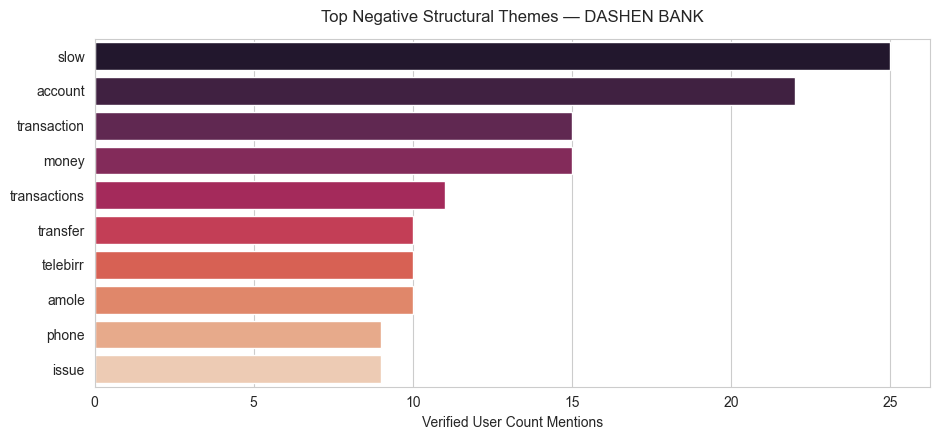

In [45]:
# 6. PLOTS 3 & 4: Cleansed Sentiment Keyword Extractions & WordClouds Loop
banks = df["bank_name"].unique()

for bank in banks:
    bank_reviews = df[df["bank_name"] == bank]
    bank_filename = bank.lower().replace(" ", "_")
    
    # Step A: Generate Split-Sentiment Horizontal Frequency Charts
    for sentiment, palette_theme in [("Positive", "viridis"), ("Negative", "rocket")]:
        sent_df = bank_reviews[bank_reviews["sentiment_label"] == sentiment]
        words_pool = []
        for text in sent_df["review_text"].dropna():
            words_pool.extend(clean_tokens(text))
            
        top_sentiment_keywords = Counter(words_pool).most_common(10)
        if not top_sentiment_keywords:
            continue
            
        keywords_df = pd.DataFrame(top_sentiment_keywords, columns=["keyword", "count"])
        
        plt.figure(figsize=(9.5, 4.5))
        sns.barplot(data=keywords_df, x="count", y="keyword", palette=palette_theme)
        plt.title(f"Top {sentiment} Structural Themes — {bank.upper()}", pad=12)
        plt.xlabel("Verified User Count Mentions")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig(f"../reports/figures/{bank_filename}_{sentiment.lower()}_keywords.png", dpi=300)
        plt.show()


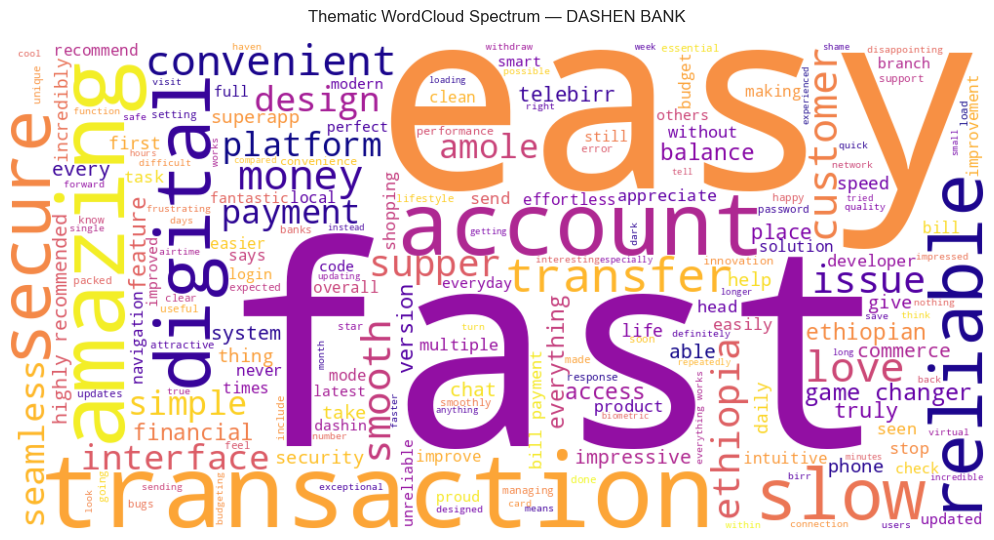

In [46]:
all_clean_words = []
for text in bank_reviews["review_text"].dropna():
    all_clean_words.extend(clean_tokens(text))
        
if all_clean_words:
    cleaned_cloud_text = " ".join(all_clean_words)
    wordcloud = WordCloud(
            width=1000, height=500, 
            background_color="white", 
            colormap="plasma"
        ).generate(cleaned_cloud_text)
        
    plt.figure(figsize=(11, 5.5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Thematic WordCloud Spectrum — {bank.upper()}", pad=15)
    plt.tight_layout()
    plt.savefig(f"../reports/figures/{bank_filename}_wordcloud.png", dpi=300)
    plt.show()

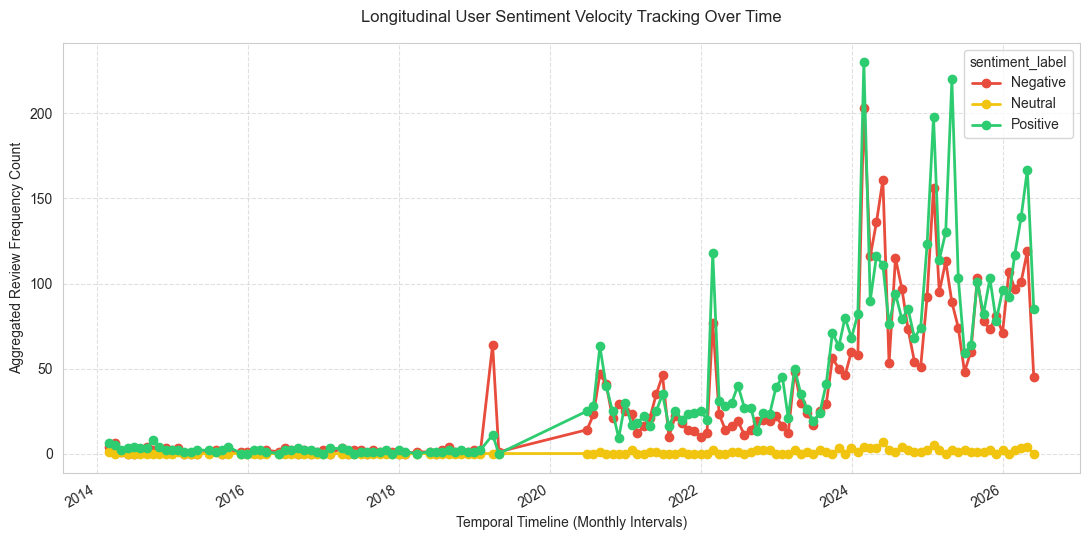

In [47]:
# 7. PLOT 5: Longitudinal Sentiment Trends Over Timeline Matrix
if "review_date" in df.columns:
    df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
    
    if not df["review_date"].isna().all():
        trend_df = df.groupby([pd.Grouper(key="review_date", freq="ME"), "sentiment_label"]).size().unstack(fill_value=0)
        
        # Plot with explicit custom structural colors matching Plot 1
        trend_df.plot(figsize=(11, 5.5), marker="o", linewidth=2, color=['#e74c3c', '#f1c40f', '#2ecc71'])
        plt.title("Longitudinal User Sentiment Velocity Tracking Over Time", pad=15)
        plt.xlabel("Temporal Timeline (Monthly Intervals)")
        plt.ylabel("Aggregated Review Frequency Count")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.savefig("../reports/figures/sentiment_trend.png", dpi=300)
        plt.show()


In [48]:
print("========================================")
print("TASK 4 REPORT: INSIGHTS & RECOMMENDATIONS")
print("========================================")

# ---------------------------------------------------
# ETHICS NOTE
# ---------------------------------------------------
print("\n--- ETHICS & BIAS NOTE ---")
print("Negativity Bias: Users are more likely to submit reviews after bad experiences.")
print("Sampling Bias: Reviews may not represent all customer demographics or app versions.")

# ---------------------------------------------------
# STOPWORDS (Expanded to catch leaked terms)
# ---------------------------------------------------
stopwords = set([
    # Common English
    "the", "and", "for", "that", "this", "with", "have", "from", "your",
    "they", "their", "there", "about", "would", "could", "should", "very", 
    "just", "been", "you", "are", "was", "were", "but", "not", "can", "when", 
    "what", "why", "how", "all", "any", "our", "out", "get", "got", "had", 
    "has", "did", "does", "doing",

    # Weak filler & Leaks
    "after", "doesn", "even", "more", "time", "other", "ever", "need", "really",
    "some", "only", "make", "most", "much", "open", "apps", "better", "well", 
    "always", "keep", "will", "than", "using", "used", "previous", "ahead", 
    "step", "than","sometimes", "because", "option", "needs",  "services","thanks", "before", "keeps", "many", "show"

    # Generic praise & Review filler
    "thanks", "thank", "good", "best", "great", "nice", "awesome", "excellent",
    "service", "like", "please", "user", "features", "friendly", "experience",

    # Bank words & Technical fillers
    "app", "bank", "dashen", "cbe", "abyssinia", "banking", "mobile", 
    "application", "work", "working", "update", "problem", "worst", "super"
])

# ---------------------------------------------------
# TOKEN CLEANER
# ---------------------------------------------------
def clean_tokens(text):
    # Extracts words with 4 or more letters
    tokens = re.findall(r'\b[a-zA-Z]{4,}\b', str(text).lower())
    return [word for word in tokens if word not in stopwords]

# ---------------------------------------------------
# BANK REPORTS LOOP
# ---------------------------------------------------
for bank in banks:

    print(f"\n========================================")
    print(f"BANK REPORT: {bank.upper()}")
    print(f"========================================")

    bank_reviews = df[df["bank_name"] == bank]

    # Positive Reviews Extraction
    positive_reviews = bank_reviews[bank_reviews["sentiment_label"] == "Positive"]
    positive_words = []
    for text in positive_reviews["review_text"].dropna():
        positive_words.extend(clean_tokens(text))
    positive_common = Counter(positive_words).most_common(10)

    # Negative Reviews Extraction
    negative_reviews = bank_reviews[bank_reviews["sentiment_label"] == "Negative"]
    negative_words = []
    for text in negative_reviews["review_text"].dropna():
        negative_words.extend(clean_tokens(text))
    negative_common = Counter(negative_words).most_common(10)

    # ---------------------------------------------------
    # DISPLAY: SATISFACTION DRIVERS
    # ---------------------------------------------------
    print("\n📈 Top Satisfaction Drivers:")
    if positive_common:
        for word, count in positive_common:
            print(f" - '{word}' mentioned {count} times in positive reviews")
    else:
        print(" - No sufficient positive review data.")

    # ---------------------------------------------------
    # DISPLAY: PAIN POINTS
    # ---------------------------------------------------
    print("\n📉 Top Pain Points:")
    if negative_common:
        for word, count in negative_common:
            print(f" - '{word}' mentioned {count} times in negative reviews")
    else:
        print(" - No sufficient negative review data.")

    # ---------------------------------------------------
    # DISPLAY: SMART PRODUCT RECOMMENDATIONS
    # ---------------------------------------------------
    print("\n💡 Product Recommendations:")
    
    # Tracking set to eliminate duplicates per bank
    printed_recommendations = set()

    for word, count in negative_common:
        rec_text = None

        # Technical Stability & Crash Monitoring
        if word in ["crash", "crashes", "freeze", "bug", "developer"]:
            rec_text = " - Strengthen stability monitoring, resolve codebase errors, and increase QA regression testing."

        # Money, Core Transactions & Transfers
        elif word in ["transfer", "transaction", "transactions", "money", "balance"]:
            rec_text = " - Improve transaction retry logic, optimize core ledger syncing, and deploy descriptive error messages."

        # Backend Performance & Network Issues
        elif word in ["slow", "loading", "lag"]:
            rec_text = " - Optimize backend APIs and database queries to reduce application loading latency."

        # Authentication, System Access & Sign-ins
        elif word in ["code", "otp", "verification", "phone", "account"]:
            rec_text = " - Improve SMS gateway reliability, clear account locked states, and streamline registration verification."
        elif word in ["telebirr", "amole"]:
            rec_text = " - Audit and optimize third-party payment gateway integrations to resolve payment routing timeouts."

        # App Versions & Backward Compatibility
        elif word in ["version", "update"]:
            rec_text = " - Review backward compatibility configurations for legacy OS builds and evaluate post-release patch health."

        # Print the recommendation only if it has not been printed yet for this bank
        if rec_text and rec_text not in printed_recommendations:
            print(rec_text)
            printed_recommendations.add(rec_text)

    if not printed_recommendations:
        print(" - Continue monitoring app performance and maintain current user experience levels.")

TASK 4 REPORT: INSIGHTS & RECOMMENDATIONS

--- ETHICS & BIAS NOTE ---
Negativity Bias: Users are more likely to submit reviews after bad experiences.
Sampling Bias: Reviews may not represent all customer demographics or app versions.

BANK REPORT: CBE BANK

📈 Top Satisfaction Drivers:
 - 'easy' mentioned 332 times in positive reviews
 - 'fast' mentioned 192 times in positive reviews
 - 'simple' mentioned 109 times in positive reviews
 - 'ethiopia' mentioned 107 times in positive reviews
 - 'amazing' mentioned 102 times in positive reviews
 - 'love' mentioned 97 times in positive reviews
 - 'transaction' mentioned 68 times in positive reviews
 - 'life' mentioned 66 times in positive reviews
 - 'money' mentioned 59 times in positive reviews
 - 'transfer' mentioned 55 times in positive reviews

📉 Top Pain Points:
 - 'transaction' mentioned 212 times in negative reviews
 - 'money' mentioned 188 times in negative reviews
 - 'account' mentioned 185 times in negative reviews
 - 'transfer' men

In [49]:
print("\n========================================")
print("BANK COMPARISON SUMMARY")
print("========================================")

# Highest Rated Bank
best_bank = avg_rating.idxmax()
best_score = avg_rating.max()

print(f"\n🏆 Highest Rated Bank: {best_bank} ({best_score:.2f}/5)")

# Lowest Rated Bank
worst_bank = avg_rating.idxmin()
worst_score = avg_rating.min()

print(f"⚠ Lowest Rated Bank: {worst_bank} ({worst_score:.2f}/5)")

# Most Positive Sentiment
positive_counts = (
    df[df["sentiment_label"] == "Positive"]
    .groupby("bank_name")
    .size()
)

most_positive_bank = positive_counts.idxmax()

print(f"😊 Most Positive Reviews: {most_positive_bank}")

# Most Negative Sentiment
negative_counts = (
    df[df["sentiment_label"] == "Negative"]
    .groupby("bank_name")
    .size()
)

most_negative_bank = negative_counts.idxmax()

print(f"😡 Most Negative Reviews: {most_negative_bank}")


BANK COMPARISON SUMMARY

🏆 Highest Rated Bank: Dashen Bank (4.04/5)
⚠ Lowest Rated Bank: Bank of Abyssinia (2.96/5)
😊 Most Positive Reviews: CBE Bank
😡 Most Negative Reviews: CBE Bank
